In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"

In [2]:
# from google.colab import drive
# drive.mount('/content/gdrive')
# DATA_PATH = '/content/gdrive/MyDrive/REU/PROJECT/DATA/'

In [3]:
annotated_data = pd.read_csv(DATA_PATH+"annotated_data.csv")
non_annotated_data = pd.read_csv(DATA_PATH+"non_annotated_data.csv")


In [4]:
annotated_data.sort_values('full_name')

,Unnamed: 0,full_name,transactor_type
9580,56501,citizens for boyle,Committee
8800,51003,"mauck, shawn c",Candidate
360485,633109,!jayne 2012,Committee
95841,101399,"""""rip"""" stephen wilson",Individual
323972,544149,"""a company, inc. phx portable restooms""",Company
...,...,...,...
94328,99504,zylphia cummins,Individual
193258,249665,zymages,Company
433906,832708,zyra brown,Individual
442010,851959,\tindependentvoting.org,Company


In [5]:
annotated_data = annotated_data.dropna(subset=['full_name'])
annotated_data.sort_values('full_name')

,Unnamed: 0,full_name,transactor_type
9580,56501,citizens for boyle,Committee
8800,51003,"mauck, shawn c",Candidate
360485,633109,!jayne 2012,Committee
95841,101399,"""""rip"""" stephen wilson",Individual
323972,544149,"""a company, inc. phx portable restooms""",Company
...,...,...,...
353475,613913,zygmunt roguski,Individual
94328,99504,zylphia cummins,Individual
193258,249665,zymages,Company
433906,832708,zyra brown,Individual


In [6]:
non_annotated_data = non_annotated_data.dropna(subset=['full_name'])

In [7]:
non_annotated_data.sort_values('full_name')


,Unnamed: 0,full_name,transactor_type
832493,933440,"\tcharlton, alexander t friends of",NaN
193934,211766,\r\njohn fowler,NaN
248413,271020,\r\nnorth country supv union,NaN
838025,939874,sue cannon,NaN
838024,939873,shawn cannon,NaN
...,...,...,...
651456,720928,zyon w manning,NaN
939222,615590,zyril e bassett,NaN
592385,653610,"zyroff, ellen",NaN
667178,738615,zyrome brown,NaN


<h1>INDIVIDUAL AND ORGANIZATION</h1>

In [8]:
def org_labels(st):
    if st != "Individual" and st != "Candidate":
        return "Organization"
    return "Individual"

In [9]:
annotated_data.groupby('transactor_type').size()

transactor_type
Candidate       1952
Committee      30284
Company        46271
Individual    439704
Party             75
dtype: int64

In [10]:
annotated_data['transactor_type'] = annotated_data['transactor_type'].apply(org_labels)
annotated_data = annotated_data[['full_name', 'transactor_type']]

In [11]:
annotated_data.groupby('transactor_type').size()

transactor_type
Individual      441656
Organization     76630
dtype: int64

<h1>LOGISTIC REGRESSION FOR BINARY CLASS CLASSIFICATION.</h1>
<p>By: Jakob</p>


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# preprocessing
# Features and target
X = annotated_data['full_name'] # name
y = annotated_data['transactor_type'] # label

# Convert names to numeric features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = vectorizer.fit_transform(X.fillna(''))  # Handle NaN

# split
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=24)

In [13]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [14]:
# Predict
predictions = model.predict(X_test)

In [15]:
# scores
# Evaluate
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

  Individual       0.93      0.99      0.96    132591
Organization       0.94      0.58      0.72     22895

    accuracy                           0.93    155486
   macro avg       0.94      0.79      0.84    155486
weighted avg       0.93      0.93      0.93    155486



<h1>RANDOM FOREST FOR BINARY CLASS CLASSIFICATION.</h1>
<p>By: Drew</p>

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# df = pd.read_csv("data\pa_transactor_annotaded_clean.csv")
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(annotated_data['full_name'])

In [17]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Organization':
        return 1
    else:
        return 0
y = np.vectorize(convert_bool)(annotated_data['transactor_type'])

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [19]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
predicted = rfc.predict(X_val)

In [20]:
accuracy = accuracy_score(y_val, predicted) * 100

recall = recall_score(y_val, predicted) * 100

precision = precision_score(y_val, predicted) * 100

f1 = f1_score(y_val, predicted) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 93.53641218781836
Recall: 85.31748091999377
Precision: 74.7634212920837
f1_score: 79.6925389782013


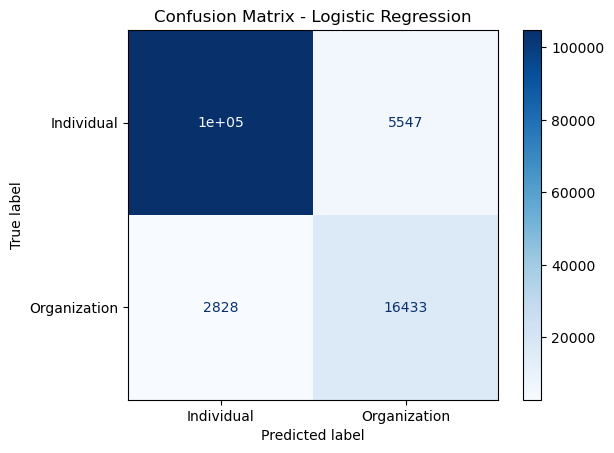

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_val, predicted, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<h1>?? FOR BINARY CLASS CLASSIFICATION.</h1>